# Ensemble Methods in RAG 

We're going to build a retrieval system for *The Godfather* — then make it progressively smarter using ensemble techniques.

Here's the journey:
```mermaid
flowchart LR
    A[📄 Raw Text] --> B[Chunking]
    B --> C[4 Baseline Retrievers]
    C --> D[Feature Matrix]
    D --> E[Meta-Ranker Training]
    E --> F[Stacking Ensemble]
    E --> G[Boosting Ensemble]
    F --> H[📊 Evaluation]
    G --> H
```

**The core idea:** instead of picking one retrieval strategy and hoping for the best, we let multiple retrievers vote — then train a model to learn *which votes to trust*.


In [1]:
# Libraries
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

from sklearn.ensemble import GradientBoostingClassifier
import bm25s
import time
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
import os
from IPython.display import Image, display


# Data Collection

Dataset consists of an online pdf of "The Godfather" by XYZ
- Large Corpus

## Data Preparation

### 1. Chunking Strategy & Cleaning
The overall Chunking Strategy and data cleaning is outside of the scope of this module. However, as a friendly reminder, it generally takes up a lot more time than model training!

I chose this data source for a few additional reasons, namely it required a lot of data cleaning! In brief I did the following:
- Detected page content borders and extracted content only from within those borders
- Detected hierarchical separation (3 levels) of content (Titles, Chapters, sub-chapters etc.) using regular expressions and font/format analysis
- Detected paragraphs within hierarchy using line spacing and positioning
- Created chunks by identifying mean paragraph size and normalising for paragraphs X% above (splitting) or below (joining)mean paragraph size within lowest hierarchy (Level 3)

### 2. Section summarisation (analysis out of scope due to time constraints)
In order for a more interesting and practical demonstration of ensemble methods, I used a small open-source LLM (Qwen3-4B-Instruct-2507) to generate entity-dense, fact-based summaries of each section

### 3. Query Generation
In addition, I ran the same open-source LLM to generate a query for each chunk that is only answerable from the text within that chunk

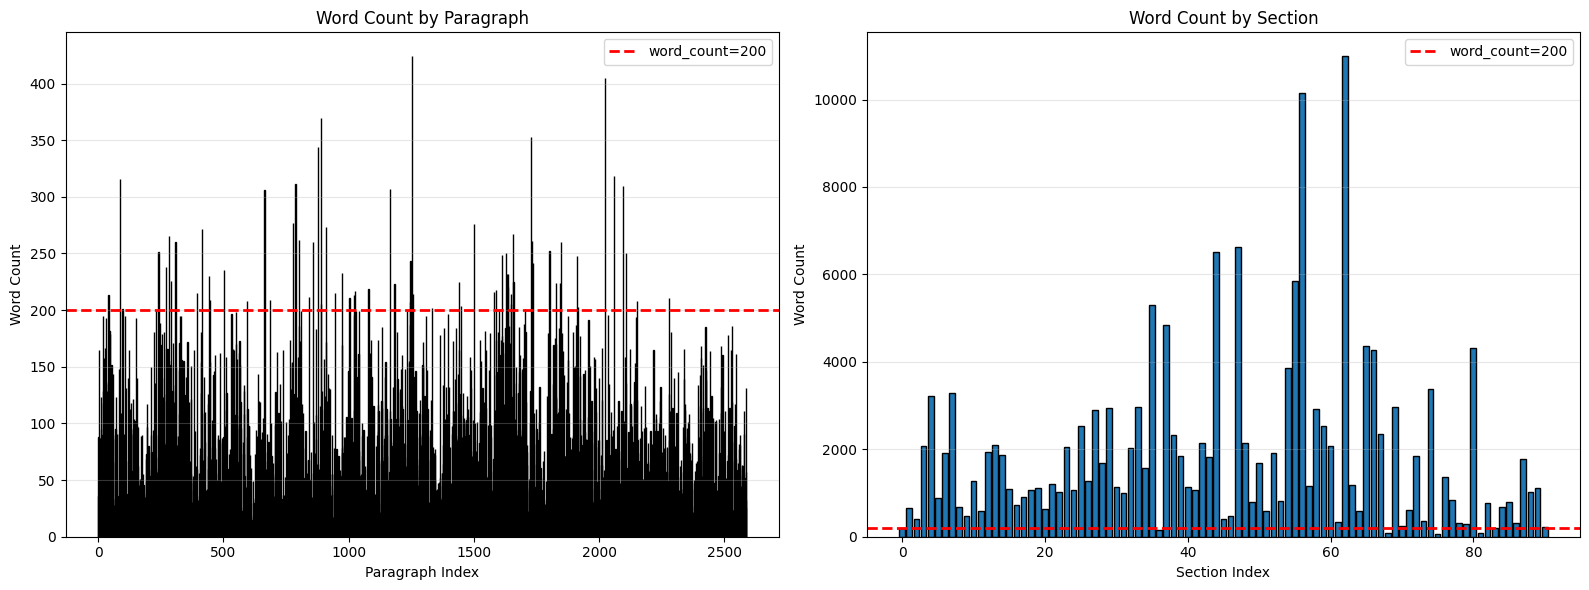

In [147]:
from IPython.display import Image, display
display(Image(filename="../images/dataprep.png"))

add this image from this path images/dataprep.png

In [2]:
pd.set_option('display.max_colwidth', None)
df_godfather = pd.read_csv("../datasets/godfather_chunks_sec10_summ_prompt.csv")

df_godfather = df_godfather.drop(columns=['Unnamed: 0'], errors='ignore')
df_godfather.tail(1)

,chunk_id,content,section_str,section_summary,generated_query
100,100,"Abbandando fell back on the pillow. His eyes lost their wild gleam of hope. The nurse came back into the room and started shooing them out in a very matter-of-fact way. The Don got up but Abbandando put out his hand. “Godfather,” he said, “stay here with me and help me meet death. Perhaps if He sees you near me He will be frightened and leave me in peace. Or perhaps you can say a word, pull a few strings, eh?” The dying man winked as if he were mocking the Don, now not really serious. “You’re brothers in blood, after all.” Then, as if fearing the Don would be offended, he clutched at his hand. “Stay with me, let me hold your hand. We’ll outwit that bastard as we’ve outwitted others. Godfather, don’t betray me.” The Don motioned the other people out of the room. They left. He took the withered claw of Genco Abbandando in his own two broad hands. Softly, reassuringly, he comforted his friend, as they waited for death together. As if the Don could truly snatch the life of Gencp Abbandando back from that most foul and criminal traitor to man.",1-1-10,"Genco Abbandando, a cancer patient, dies in a hospital corridor; his wife and daughters, dressed in black, seek comfort from Don Corleone, a powerful Mafia figure. Don, though initially dismissive, stays with him, offering emotional support. Abbandando, delirious, pleads for divine intervention, referencing their childhood bond. Don refuses supernatural power, affirming prayer and moral duty. The scene reflects familial grief, delirium, and the stark reality of mortality—no miracles, only human compassion in the face of death.","Who did Genco Abbandando ask to stay with him to help him meet death, and what did he imply about their relationship?"


In [8]:
# Unique chunks (one row per chunk_id)
chunks = (df_godfather[["chunk_id", "content", "section_str"]].drop_duplicates("chunk_id").sort_values("chunk_id").reset_index(drop=True))

# Unique section summaries (one row per section_str)
summaries = (df_godfather[["section_str", "section_summary"]].drop_duplicates("section_str").sort_values("section_str").reset_index(drop=True))

print("chunks:", chunks.shape, "| summaries:", summaries.shape)

chunks: (100, 3) | summaries: (11, 2)


## Model Selection

### Why Four Retrievers?

Each retriever sees the world differently. A query like *"who ordered the hit on Sonny?"* might be answered well by semantic search (understands meaning) but poorly by TF-IDF (looks for exact words).
```mermaid
flowchart TD
    Q[🔍 Query] --> COS[Cosine Similarity\nNormalized embeddings\nAngle between vectors]
    Q --> DOT[Dot Product\nRaw embeddings\nMagnitude matters]
    Q --> TFIDF[TF-IDF\nTerm frequency\nExact keyword match]
    Q --> BM25[BM25\nProbabilistic\nDocument length aware]

    COS -->|top-k chunks| POOL
    DOT -->|top-k chunks| POOL
    TFIDF -->|top-k chunks| POOL
    BM25 -->|top-k chunks| POOL

    POOL[🗂 Candidate Pool\nUnion of all results]
```

No single retriever wins every time. That's exactly why ensembles exist.

In [137]:
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL_NAME)

def embed_texts(texts, normalize=True, batch_size=64):
    emb = embedder.encode(
        list(map(str, texts)),
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=normalize,
    ).astype(np.float32)
    return emb

# Chunk embeddings
E_chunks_cos = embed_texts(chunks["content"], normalize=True) 
E_chunks_raw = embed_texts(chunks["content"], normalize=False)  

### Lexical Retrieval

In [ ]:

def tf_idf_matrix(df, corpus_col):
    corpus = df[corpus_col].astype(str).tolist()
    vectorizer= TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
    matrix = vectorizer.fit_transform(corpus)
    return vectorizer, matrix

tfidf_vectorizer, tfidf_matrix = tf_idf_matrix(chunks, "content")



def build_bm25(df, corpus_col):
    corpus = df[corpus_col].astype(str).tolist()
    corpus_tokens = bm25s.tokenize(corpus, stopwords='english')
    bm25_algo = bm25s.BM25()
    bm25_algo.index(corpus_tokens)
    return bm25_algo

bm25_retriever = build_bm25(chunks, "content")




Split strings:   0%|          | 0/100 [00:00<?, ?it/s]

BM25S Count Tokens:   0%|          | 0/100 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/100 [00:00<?, ?it/s]

### Query-to-Chunk Search

In [135]:
def topk_idx(scores: np.ndarray, k: int) -> np.ndarray:
    k = min(k, len(scores))
    idx = np.argpartition(-scores, k-1)[:k]
    return idx[np.argsort(-scores[idx])]

In [136]:
def retrieve_chunk_cos(query: str, k: int = 10):
    q = embed_texts([query], normalize=True)[0]
    scores = E_chunks_cos @ q
    idx = topk_idx(scores, k)
    return idx, scores[idx], scores

def retrieve_chunk_dot(query: str, k: int = 10):
    q = embed_texts([query], normalize=False)[0]
    scores = E_chunks_raw @ q
    idx = topk_idx(scores, k)
    return idx, scores[idx], scores

def retrieve_tfidf(query: str, k: int = 10):
    q = tfidf_vectorizer.transform([query])
    scores = (tfidf_matrix @ q.T).toarray().ravel()
    idx = topk_idx(scores, k)
    return idx, scores[idx]


def retrieve_bm25(query: str, k: int = 10):
    q = str(query).lower().split()
    scores = bm25_retriever.get_scores(q)
    idx = topk_idx(scores, k)
    return idx, scores[idx]



## Evaluation

### What Are We Measuring?

Before we go further, let's be clear on what "better retrieval" actually means.

| Metric | Question it answers |
|--------|-------------------|
| **Recall@1** | Was the right chunk the very top result? |
| **Recall@5** | Was the right chunk anywhere in the top 5? |
| **MRR** | On average, how high did the right chunk rank? |
| **Time p95** | How slow are the worst 5% of queries? |

> 💡 **Why MRR over accuracy?** Ranking 2nd is much better than ranking 20th — accuracy doesn't capture that. MRR rewards systems that consistently put the right answer near the top.

In [63]:
def recall_at_k(ranked_chunk_ids, true_chunk_id, k: int) -> float:
    return 1.0 if int(true_chunk_id) in list(map(int, ranked_chunk_ids[:k])) else 0.0

def mrr(ranked_chunk_ids, true_chunk_id) -> float:
    true_chunk_id = int(true_chunk_id)
    for i, cid in enumerate(map(int, ranked_chunk_ids), start=1):
        if cid == true_chunk_id:
            return 1.0 / i
    return 0.0

def time_call(fn, *args, **kwargs):
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    end = time.perf_counter()
    latency_ms = (end - start) * 1000.0
    return result, latency_ms

In [124]:
def eval_retriever(df_eval: pd.DataFrame, retriever_fn, k: int = 10):
    rec1 = []
    rec5 = []
    rr = []
    latencies = []

    for _, r in df_eval.iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        (idx, *_), latency_ms = time_call(retriever_fn, q, k=k)
        latencies.append(latency_ms)

        ranked_ids = chunks.iloc[idx]["chunk_id"].tolist()

        rec1.append(recall_at_k(ranked_ids, true_id, 1))
        rec5.append(recall_at_k(ranked_ids, true_id, 5))
        rr.append(mrr(ranked_ids, true_id))

    return {
        "Recall@1": round(float(np.mean(rec1)), 2),
        "Recall@5": round(float(np.mean(rec5)), 2),
        "MRR": round(float(np.mean(rr)), 2),
        "Time_p95": round(float(np.percentile(latencies, 95)), 2), # Latency in ms
    }



## 🥞 Stacking — Teaching a Model to Rank

Stacking asks: *"Given that each retriever has already had its say, can we learn which signals to trust?"*
```mermaid
flowchart TD
    Q[Query] --> R1[Retriever 1\nCosine]
    Q --> R2[Retriever 2\nDot Product]
    Q --> R3[Retriever 3\nTF-IDF]
    Q --> R4[Retriever 4\nBM25]

    R1 -->|rank + score| FM[Feature Matrix\none row per candidate chunk]
    R2 -->|rank + score| FM
    R3 -->|rank + score| FM
    R4 -->|rank + score| FM

    FM -->|label: 1 if relevant, 0 if not| LR[Meta-Ranker\nLogistic Regression]
    LR -->|P relevant| RANK[Re-ranked Results]
```

### Why ranks rather than raw scores?

Raw scores are not comparable across retrievers — a BM25 score of 4.2 and a cosine similarity of 0.87 live on completely different scales. Converting to ranks normalises everything: rank 1 means "this retriever's top pick" regardless of the underlying model.

### The Training Setup

Each training example is a `(query, candidate_chunk)` pair. The label is `1` if that chunk is the true answer, `0` otherwise. With ~20 candidates per query and only 1 correct answer, the dataset is heavily imbalanced — hence `class_weight="balanced"` in the LogisticRegression.


In [ ]:
def rank_of(order: np.ndarray, idx: int) -> int:
    pos = np.where(order == idx)[0]
    return int(pos[0] + 1) if len(pos) else 10**9

In [121]:

def build_candidate_features(query: str, k_each: int = 15):
    # Retrieve Chunks using each Baseline model
    idx_cos, _, all_cos   = retrieve_chunk_cos(query, k=k_each)
    idx_dot, _, all_dot   = retrieve_chunk_dot(query, k=k_each)
    idx_tfidf, _ = retrieve_tfidf(query, k=k_each)
    idx_bm25, _ = retrieve_bm25(query, k=k_each)

    # Create a unique set of retrieved chunks
    candidates = sorted(set(idx_cos.tolist()) | set(idx_dot.tolist()) | set(idx_tfidf.tolist()) | set(idx_bm25.tolist()))

    # Generate query scores for Lexicals
    qv = tfidf_vectorizer.transform([query])
    all_tfidf = (tfidf_matrix @ qv.T).toarray().ravel()
    q_bm25 = str(query).lower().split()
    all_bm25 = bm25_retriever.get_scores(q_bm25)

    rows = []
    for r in candidates:
        r = int(r)
        chunk_id = int(chunks.iloc[r]["chunk_id"])

        rows.append({
            "chunk_id": chunk_id,

            # raw scores
            "cos_chunk": float(all_cos[r]),
            "dot_chunk": float(all_dot[r]),
            "tfidf_chunk": float(all_tfidf[r]),
            "bm25_chunk": float(all_bm25[r]),

            # ranks (within each retriever list) --> use ranks to avoid normalising raw scores
            "rank_cos": rank_of(idx_cos, r),
            "rank_dot": rank_of(idx_dot, r),
            "rank_tfidf": rank_of(idx_tfidf, r),
            "rank_bm25": rank_of(idx_bm25, r),

        })

    return pd.DataFrame(rows)

def build_retriever_feature_matrix(df: pd.DataFrame, k_each: int = 15):
    rows = []
    for _, r in df.reset_index(drop=True).iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        feats = build_candidate_features(q, k_each=k_each)
        feats["query_id"] = true_id
        feats["query"] = q
        feats["true_chunk_id"] = true_id
        feats["label_relevant"] = (feats["chunk_id"] == true_id).astype("int32")
        rows.append(feats)

    return pd.concat(rows, ignore_index=True)

retriever_features = build_retriever_feature_matrix(df_godfather, k_each=20)



In [127]:
feature_cols = ["rank_cos", "rank_dot", "rank_tfidf","rank_bm25"]

X = retriever_features[feature_cols].astype(np.float32).values
y = retriever_features["label_relevant"].astype(int).values

# Split by query to avoid leakage across candidates of the same query
unique_q = retriever_features["query_id"].unique()
q_train, q_test = train_test_split(unique_q, test_size=0.2, random_state=42)

train_mask = retriever_features["query_id"].isin(q_train).values
test_mask = retriever_features["query_id"].isin(q_test).values

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

df_test = df_godfather.reset_index(drop=True).iloc[q_test].reset_index(drop=True)

### Baseline Results — What Are We Trying to Beat?

Run the cell above to see how each retriever performs in isolation. You'll likely notice:

- **Lexical** (TF-IDF, BM25) is fast (sub-millisecond) but misses semantic meaning
- **Semantic** (cos, dot) handles paraphrasing well but is slower and can miss keyword-heavy queries
- No single retriever dominates on all metrics

This is the *motivation* for everything that follows.

In [125]:
baseline_results = pd.DataFrame([
    {"retriever": "embed_cos", **eval_retriever(df_test, retrieve_chunk_cos, k=10)},
    {"retriever": "embed_dot", **eval_retriever(df_test, retrieve_chunk_dot, k=10)},
    {"retriever": "lex_tfidf", **eval_retriever(df_test, retrieve_tfidf, k=10)},
    {"retriever": "lex_bm25",  **eval_retriever(df_test, retrieve_bm25, k=10)},
])

baseline_results

,retriever,Recall@1,Recall@5,MRR,Time_p95
0,embed_cos,0.80,0.90,0.85,9.79
1,embed_dot,0.80,0.90,0.85,6.67
2,lex_tfidf,0.75,0.95,0.84,0.19
3,lex_bm25,0.70,0.95,0.82,0.04


In [130]:
stacking_method = LogisticRegression(max_iter=2000, class_weight="balanced")
stacking_method.fit(X_train, y_train)

def stacking_ensemble(df, k_each: int = 20):
    rec1 = []
    rec5 = []
    rr = []
    latencies = []

    for _, r in df.iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        start = time.perf_counter()

        feats = build_candidate_features(q, k_each=k_each)
        Xq = feats[feature_cols].astype(np.float32).values
        p = stacking_method.predict_proba(Xq)[:, 1]

        order = np.argsort(-p)
        ranked_chunk_ids = feats.iloc[order]["chunk_id"].tolist()

        end = time.perf_counter()
        latencies.append((end - start) * 1000.0)

        rec1.append(recall_at_k(ranked_chunk_ids, true_id, 1))
        rec5.append(recall_at_k(ranked_chunk_ids, true_id, 5))
        rr.append(mrr(ranked_chunk_ids, true_id))

    return {
        "Recall@1": round(float(np.mean(rec1)), 2),
        "Recall@5": round(float(np.mean(rec5)), 2),
        "MRR": round(float(np.mean(rr)), 2),
        "Time_p95": round(float(np.percentile(latencies, 95)), 2),
    }

stacking_results = stacking_ensemble(df_test, k_each=20)

## 🚀 Boosting — Learning From Mistakes

Stacking trains one meta-ranker on the full feature set. Boosting goes further — it trains an *ensemble of trees sequentially*, each one focusing harder on the examples the previous trees got wrong.
```mermaid
flowchart LR
    D[Training Data] --> T1[Tree 1]
    T1 -->|residuals\nhard examples weighted up| T2[Tree 2]
    T2 -->|residuals| T3[Tree 3]
    T3 -->|...| TN[Tree N]
    TN --> PRED[Final Score\nweighted sum]
```

### Stacking vs Boosting — When Does Each Win?

| | Stacking | Boosting |
|---|---|---|
| **Model** | Logistic Regression | Gradient Boosted Trees |
| **Learns** | Linear combination of retriever signals | Non-linear patterns, hard examples |
| **Risk** | Underfits if signals aren't linearly separable | Overfits more easily on small datasets |
| **Speed** | Fast inference | Slightly slower |

> 💡 **Watch the numbers:** on a small corpus like this, boosting's Recall@1 will look suspiciously high. That's a feature of small datasets — in production with thousands of queries you'd see the gap between the two methods narrow.

In [129]:
boosting_method = GradientBoostingClassifier(random_state=42)
boosting_method.fit(X_train, y_train)


def boosting_ensemble(df, k_each: int = 20):
    rec1 = []
    rec5 = []
    rr = []
    latencies = []

    for _, r in df.iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        start = time.perf_counter()

        feats = build_candidate_features(q, k_each=k_each)
        Xq = feats[feature_cols].astype(np.float32).values
        p = boosting_method.predict_proba(Xq)[:, 1]

        order = np.argsort(-p)
        ranked_chunk_ids = feats.iloc[order]["chunk_id"].tolist()

        end = time.perf_counter()
        latencies.append((end - start) * 1000.0)

        rec1.append(recall_at_k(ranked_chunk_ids, true_id, 1))
        rec5.append(recall_at_k(ranked_chunk_ids, true_id, 5))
        rr.append(mrr(ranked_chunk_ids, true_id))

    return {
        "Recall@1": round(float(np.mean(rec1)), 2),
        "Recall@5": round(float(np.mean(rec5)), 2),
        "MRR": round(float(np.mean(rr)), 2),
        "Time_p95": round(float(np.percentile(latencies, 95)), 2),
    }

boosting_results = boosting_ensemble(df_test, k_each=20)


In [138]:
rows = []

if "baseline_results" in globals():
    for _, r in baseline_results.iterrows():
        rows.append({
            "retriever": r["retriever"],
            "Recall@1": r["Recall@1"],
            "Recall@5": r["Recall@5"],
            "MRR": r["MRR"],
            "Time_p95": r["Time_p95"],
        })

if "stacking_results" in globals():
    rows.append({
        "retriever": "stacking_logr",
        "Recall@1": stacking_results["Recall@1"],
        "Recall@5": stacking_results["Recall@5"],
        "MRR": stacking_results["MRR"],
        "Time_p95": stacking_results["Time_p95"],
    })

if "boosting_results" in globals():
    rows.append({
        "retriever": "boosting_gbdt",
        "Recall@1": boosting_results["Recall@1"],
        "Recall@5": boosting_results["Recall@5"],
        "MRR": boosting_results["MRR"],
        "Time_p95": boosting_results["Time_p95"],
    })


results_df = pd.DataFrame(rows).drop_duplicates("retriever").reset_index(drop=True)
results_df


,retriever,Recall@1,Recall@5,MRR,Time_p95
0,embed_cos,0.80,0.90,0.85,9.79
1,embed_dot,0.80,0.90,0.85,6.67
2,lex_tfidf,0.75,0.95,0.84,0.19
3,lex_bm25,0.70,0.95,0.82,0.04
4,stacking_logr,0.80,1.00,0.88,17.36
5,boosting_gbdt,0.85,0.95,0.90,15.90


## 📊 Reading the Final Results

When you see the comparison table, here's what to look for:
```mermaid
flowchart LR
    B[Baseline\nBest individual retriever] -->|How much did we gain?| S[Stacking]
    S -->|Was non-linearity worth it?| G[Boosting]
    G -->|At what cost?| L[Latency\nTime_p95]
```

**Questions worth discussing:**
1. Did the ensemble beat every baseline on Recall@1? If not, why might that be?
2. How much latency did we add? Is the accuracy gain worth it for a production system?
3. BM25 is orders of magnitude faster than semantic retrieval. How might you design a system that uses BM25 to *filter* candidates before running the slower models?

> The best retrieval system isn't always the most accurate one in isolation — it's the one that makes the right trade-offs for your application.

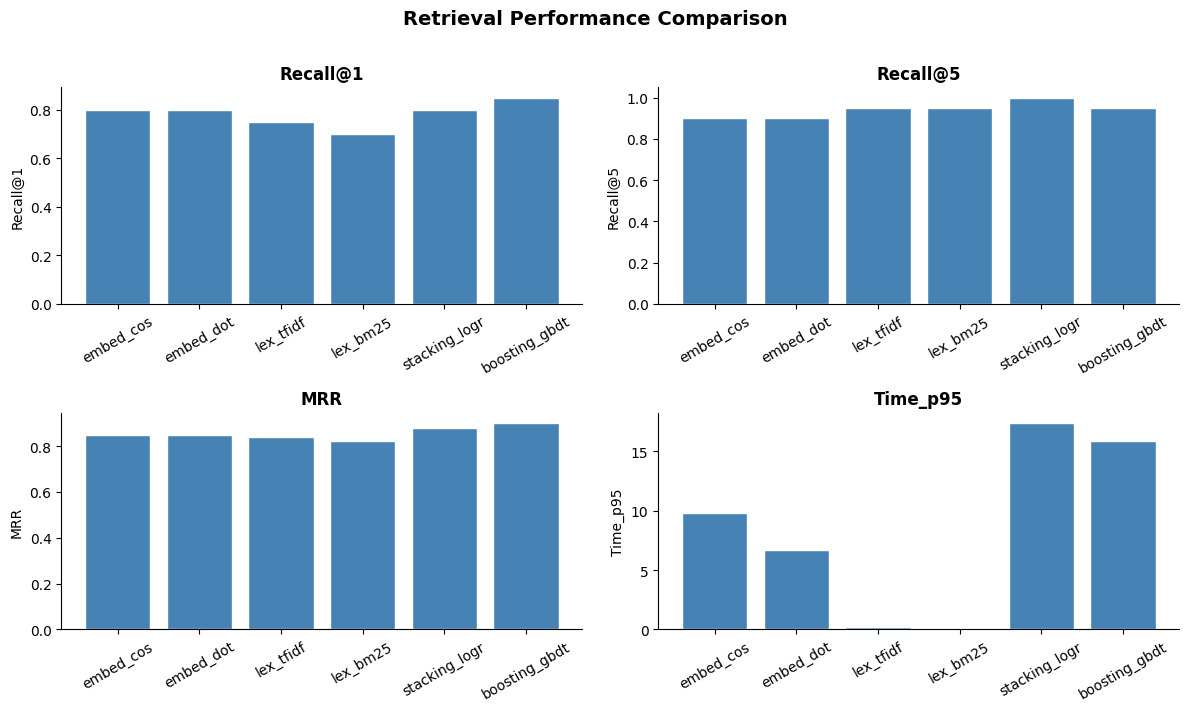

In [140]:
if len(results_df) == 0:
    raise ValueError("results_df is empty. Make sure you ran the earlier evaluation cells.")

metrics = ["Recall@1", "Recall@5", "MRR", "Time_p95"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Retrieval Performance Comparison", fontsize=14, fontweight="bold", y=1.01)

for ax, metric in zip(axes.flat, metrics):
    ax.bar(results_df["retriever"], results_df[metric], color="steelblue", edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()